In [1]:
# ==========================================
# 1. INSTALL DEPENDENCIES & IMPORTS
# ==========================================
print("📦 Installing dependencies...")
!pip install -q segmentation-models-pytorch
!pip install -q torch torchvision
!pip install -q pillow tqdm matplotlib

import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms
from torchvision.transforms import functional as TF
import torchvision.transforms as T
from torchvision.transforms import RandomApply

# PIL for image handling
from PIL import Image

# Google Colab utilities
from google.colab import files
import zipfile
import time
from datetime import datetime

print("✅ All dependencies installed and imported!")

📦 Installing dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.9 MB/s eta 0:00:00
✅ All dependencies installed and imported!


In [2]:
# ==========================================
# 2. GPU CONFIGURATION & OPTIMIZATION
# ==========================================
print("\n🔧 Configuring GPU for maximum performance...")

# Force PyTorch to use maximum GPU performance
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True
torch.cuda.empty_cache()

# Setup Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Running on: {DEVICE}")

if DEVICE.type == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"🔹 GPU: {gpu_name}")
    print(f"🔹 Memory: {gpu_memory:.2f} GB")

    # Set optimal batch sizes based on GPU
    if "T4" in gpu_name:
        LABELED_BATCH = 16    # Increased for T4
        UNLABELED_BATCH = 32
        print("🔹 Using T4-optimized batch sizes")
    elif "P100" in gpu_name:
        LABELED_BATCH = 24
        UNLABELED_BATCH = 48
    elif "V100" in gpu_name:
        LABELED_BATCH = 32
        UNLABELED_BATCH = 64
    else:
        LABELED_BATCH = 8
        UNLABELED_BATCH = 16
else:
    LABELED_BATCH = 4
    UNLABELED_BATCH = 8
    print("⚠️ Running on CPU - training will be slow!")

print("=" * 70)


🔧 Configuring GPU for maximum performance...
🚀 Running on: cuda
🔹 GPU: Tesla T4
🔹 Memory: 15.83 GB
🔹 Using T4-optimized batch sizes


In [3]:
# ==========================================
# 3. INTERACTIVE DATA UPLOAD
# ==========================================
print("\n📁 STEP 1: UPLOAD YOUR DATASET")
print("=" * 70)

# Define folder paths
IMG_DEST = "/content/dataset"
MASK_DEST = "/content/masks"

# Clean previous runs
for d in [IMG_DEST, MASK_DEST]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)

print("📁 Folder structure created:")
print(f"   Images will be saved to: {IMG_DEST}")
print(f"   Masks will be saved to: {MASK_DEST}")
print()

# Upload images
print("⬇️" * 30)
print("STEP 1: Upload ORIGINAL IMAGES Zip file (e.g., flowers.zip)")
print("⬇️" * 30)
uploaded_img = files.upload()
img_zip = list(uploaded_img.keys())[0]
print(f"✅ Uploaded: {img_zip} ({os.path.getsize(img_zip)/1024/1024:.2f} MB)")

# Upload masks
print("\n" + "⬇️" * 30)
print("STEP 2: Upload MASKS Zip file (e.g., masks_semantic.zip)")
print("⬇️" * 30)
uploaded_mask = files.upload()
mask_zip = list(uploaded_mask.keys())[0]
print(f"✅ Uploaded: {mask_zip} ({os.path.getsize(mask_zip)/1024/1024:.2f} MB)")

print("\n⏳ Extracting files...")
# Extract images
with zipfile.ZipFile(img_zip, 'r') as zip_ref:
    zip_ref.extractall(IMG_DEST)

# Extract masks
with zipfile.ZipFile(mask_zip, 'r') as zip_ref:
    zip_ref.extractall(MASK_DEST)

print("✅ Extraction complete!")
print(f"📊 Image folder: {len(os.listdir(IMG_DEST))} items")
print(f"📊 Mask folder: {len(os.listdir(MASK_DEST))} items")


📁 STEP 1: UPLOAD YOUR DATASET
📁 Folder structure created:
   Images will be saved to: /content/dataset
   Masks will be saved to: /content/masks

⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️
STEP 1: Upload ORIGINAL IMAGES Zip file (e.g., flowers.zip)
⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️


Saving archive (5).zip to archive (5).zip
✅ Uploaded: archive (5).zip (184.38 MB)

⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️
STEP 2: Upload MASKS Zip file (e.g., masks_semantic.zip)
⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️


Saving final_bw_masks.zip to final_bw_masks.zip
✅ Uploaded: final_bw_masks.zip (7.50 MB)

⏳ Extracting files...
✅ Extraction complete!
📊 Image folder: 8 items
📊 Mask folder: 7397 items



🔍 STEP 2: MATCHING IMAGES WITH MASKS
🔍 Found 7397 image files


Matching files:   0%|          | 0/7397 [00:00<?, ?it/s]


📊 DATA SUMMARY
✅ Successfully matched: 7397 pairs
⚠️  Unmatched images: 0

🔍 Sample matched pair:
   Image: Costus Speciosus Augmented 10.jpg
   Mask: Costus Speciosus Augmented 10.png


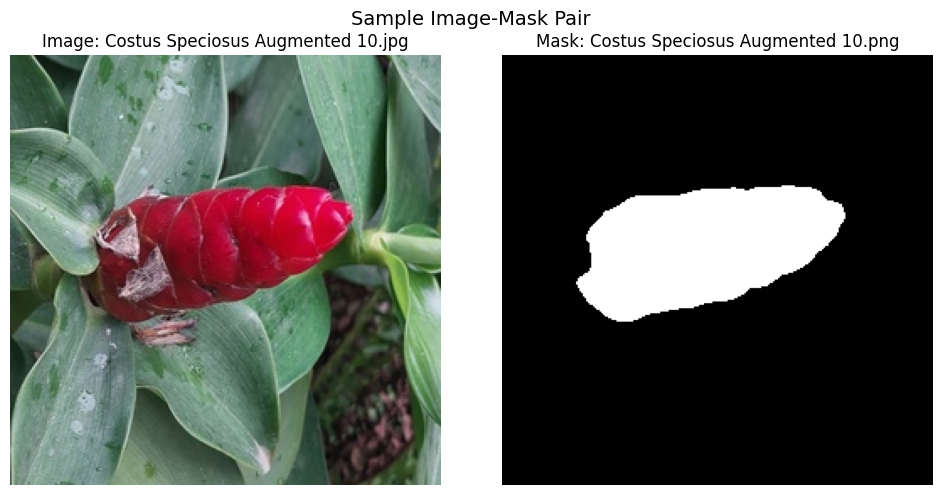

In [4]:
# ==========================================
# 4. DATA MATCHING & INSPECTION
# ==========================================
print("\n🔍 STEP 2: MATCHING IMAGES WITH MASKS")
print("=" * 70)

def match_pairs(img_folder, mask_folder):
    """Match image files with corresponding mask files"""
    valid_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

    # Get all image files
    img_paths = []
    for ext in valid_exts:
        img_paths.extend(list(Path(img_folder).rglob(f"*{ext}")))
        img_paths.extend(list(Path(img_folder).rglob(f"*{ext.upper()}")))

    img_paths = sorted(img_paths)
    print(f"🔍 Found {len(img_paths)} image files")

    # Match with masks
    pairs = []
    unmatched = []

    for img_p in tqdm(img_paths, desc="Matching files"):
        stem = img_p.stem
        # Try to find matching mask
        mask_found = False
        for ext in valid_exts:
            mask_path = Path(mask_folder) / f"{stem}{ext}"
            if mask_path.exists():
                pairs.append((str(img_p), str(mask_path)))
                mask_found = True
                break
            # Also check uppercase extension
            mask_path = Path(mask_folder) / f"{stem}{ext.upper()}"
            if mask_path.exists():
                pairs.append((str(img_p), str(mask_path)))
                mask_found = True
                break

        if not mask_found:
            unmatched.append(str(img_p))

    return pairs, unmatched

# Match pairs
pairs, unmatched = match_pairs(IMG_DEST, MASK_DEST)

print("\n" + "=" * 70)
print("📊 DATA SUMMARY")
print("=" * 70)
print(f"✅ Successfully matched: {len(pairs)} pairs")
print(f"⚠️  Unmatched images: {len(unmatched)}")

if len(unmatched) > 0:
    print("\n❌ Unmatched files (first 5):")
    for f in unmatched[:5]:
        print(f"   - {Path(f).name}")
    if len(unmatched) > 5:
        print(f"   ... and {len(unmatched)-5} more")

if len(pairs) == 0:
    raise ValueError("❌ CRITICAL ERROR: No image-mask pairs found!")

# Display sample pair
if len(pairs) > 0:
    print("\n🔍 Sample matched pair:")
    img_path, mask_path = pairs[0]
    print(f"   Image: {Path(img_path).name}")
    print(f"   Mask: {Path(mask_path).name}")

    # Show sample image and mask
    try:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        axes[0].imshow(img)
        axes[0].set_title(f"Image: {Path(img_path).name}")
        axes[0].axis('off')

        axes[1].imshow(mask, cmap='gray')
        axes[1].set_title(f"Mask: {Path(mask_path).name}")
        axes[1].axis('off')

        plt.suptitle("Sample Image-Mask Pair", fontsize=14)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"⚠️ Could not display sample: {e}")

print("=" * 70)

In [5]:
# ==========================================
# 5. DATASET CLASS DEFINITION
# ==========================================
print("\n📊 STEP 3: PREPARING DATASET FOR FIXMATCH")
print("=" * 70)

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

class FlowerDataset(Dataset):
    """PyTorch Dataset for flower segmentation"""

    def __init__(self, pairs, image_size=256, train=True):
        """
        Args:
            pairs: List of (image_path, mask_path) tuples
            image_size: Size to resize images to (square)
            train: If True, apply data augmentation
        """
        self.pairs = pairs
        self.image_size = image_size
        self.train = train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        # Get paths
        img_path, mask_path = self.pairs[idx]

        # Load image and mask
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # Resize
        img = img.resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), Image.NEAREST)

        # Data augmentation (only during training)
        if self.train and random.random() > 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)

        # Convert to tensors
        img_tensor = TF.to_tensor(img)  # Shape: [3, H, W]
        mask_tensor = TF.to_tensor(mask)  # Shape: [1, H, W]

        # Convert mask to binary (0 or 1)
        mask_tensor = (mask_tensor > 0.5).float()

        return img_tensor, mask_tensor

# Create full dataset
full_dataset = FlowerDataset(pairs, image_size=256, train=True)



📊 STEP 3: PREPARING DATASET FOR FIXMATCH


In [6]:
# ==========================================
# 6. SEMI-SUPERVISED DATA SPLITS FOR FIXMATCH
# ==========================================
print("\n📊 Creating FixMatch semi-supervised splits...")

# Total indices
indices = list(range(len(pairs)))
random.shuffle(indices)

n_total = len(indices)
n_train = int(0.8 * n_total)  # 80% for training
n_val = int(0.1 * n_total)    # 10% for validation
n_test = n_total - n_train - n_val  # 10% for testing

# Split indices
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

# Within training: 20% labeled, 80% unlabeled (for FixMatch)
n_labeled = int(0.2 * len(train_idx))
labeled_idx = train_idx[:n_labeled]
unlabeled_idx = train_idx[n_labeled:]

print("\n📊 FIXMATCH DATASET SPLITS")
print("=" * 70)
print(f"Total pairs: {n_total}")
print(f"Training (80%): {n_train} images")
print(f"  → Labeled (20%): {n_labeled} images")
print(f"  → Unlabeled (80%): {len(unlabeled_idx)} images")
print(f"Validation (10%): {n_val} images")
print(f"Test (10%): {n_test} images")
print("=" * 70)

# Create subsets
labeled_ds = Subset(full_dataset, labeled_idx)
unlabeled_ds = Subset(full_dataset, unlabeled_idx)

# Validation dataset (no augmentation)
val_dataset = FlowerDataset([pairs[i] for i in val_idx], image_size=256, train=False)
test_dataset = FlowerDataset([pairs[i] for i in test_idx], image_size=256, train=False)

# DataLoaders for FixMatch
labeled_dl = DataLoader(
    labeled_ds,
    batch_size=LABELED_BATCH,
    shuffle=True,
    num_workers=0,  # Colab compatibility
    pin_memory=True,
    drop_last=True
)

unlabeled_dl = DataLoader(
    unlabeled_ds,
    batch_size=UNLABELED_BATCH,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

val_dl = DataLoader(
    val_dataset,
    batch_size=LABELED_BATCH * 2,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_dl = DataLoader(
    test_dataset,
    batch_size=LABELED_BATCH * 2,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("✅ Data loaders created successfully!")



📊 Creating FixMatch semi-supervised splits...

📊 FIXMATCH DATASET SPLITS
Total pairs: 7397
Training (80%): 5917 images
  → Labeled (20%): 1183 images
  → Unlabeled (80%): 4734 images
Validation (10%): 739 images
Test (10%): 741 images
✅ Data loaders created successfully!


In [7]:
# ==========================================
# 7. DEEPLABV3+ MODEL DEFINITION FOR FIXMATCH
# ==========================================
print("\n🤖 STEP 4: BUILDING DEEPLABV3+ MODEL FOR FIXMATCH")
print("=" * 70)

class DeepLabV3PlusFixMatch(nn.Module):
    """DeepLabV3+ model for FixMatch framework"""
    def __init__(self, num_classes=1):
        super().__init__()
        # Load pre-trained DeepLabV3+
        self.model = models.segmentation.deeplabv3_resnet50(
            weights='DEFAULT',
            weights_backbone='DEFAULT'
        )
        # Modify for binary segmentation
        self.model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
        self.model.aux_classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)

    def forward(self, x, return_both=False):
        output = self.model(x)
        if return_both:
            return output['out'], output['aux']
        return output['out']

    def predict_with_confidence(self, x):
        """Forward pass with confidence calculation"""
        with torch.no_grad():
            output = self.model(x)
            prob = torch.sigmoid(output['out'])
            # Calculate confidence (how far from 0.5)
            confidence = torch.abs(prob - 0.5) * 2  # 0-1 scale
            return prob, confidence

def get_deeplabv3_fixmatch():
    """Create DeepLabV3+ model for FixMatch"""
    model = DeepLabV3PlusFixMatch(num_classes=1).to(DEVICE)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"✅ DeepLabV3+ FixMatch model created")
    print(f"   Parameters: {total_params:,}")
    print(f"   Device: {next(model.parameters()).device}")
    return model


🤖 STEP 4: BUILDING DEEPLABV3+ MODEL FOR FIXMATCH


In [8]:
# ==========================================
# 8. STRONG AUGMENTATIONS FOR FIXMATCH
# ==========================================
print("\n🎨 STEP 5: SETTING UP FIXMATCH AUGMENTATIONS")
print("=" * 70)

class StrongAugmentation(nn.Module):
    """Strong augmentations for FixMatch (non-geometric to preserve masks)"""
    def __init__(self, apply_prob=0.8):
        super().__init__()
        self.apply_prob = apply_prob

        # Color transformations (keep spatial alignment)
        self.color_transforms = T.Compose([
            RandomApply([T.ColorJitter(
                brightness=0.4,
                contrast=0.4,
                saturation=0.4,
                hue=0.1
            )], p=0.8),
            RandomApply([T.GaussianBlur(
                kernel_size=5,
                sigma=(0.1, 2.0)
            )], p=0.5),
            RandomApply([T.RandomAdjustSharpness(
                sharpness_factor=2,
                p=0.5
            )], p=0.3),
            RandomApply([T.RandomAutocontrast()], p=0.3),
        ])

        # Add random noise
        self.noise_std = 0.05

    def forward(self, x):
        if random.random() < self.apply_prob:
            x = self.color_transforms(x)
            # Add Gaussian noise
            if random.random() < 0.5:
                noise = torch.randn_like(x) * self.noise_std
                x = x + noise
                x = torch.clamp(x, 0, 1)
        return x

# Initialize strong augmentation
strong_aug = StrongAugmentation(apply_prob=0.8)
print("✅ Strong augmentations created:")
print("   • Color Jitter (brightness, contrast, saturation, hue)")
print("   • Gaussian Blur")
print("   • Sharpness Adjustment")
print("   • Auto Contrast")
print("   • Gaussian Noise")

# ==========================================
# 9. FIXMATCH LOSS FUNCTION
# ==========================================
print("\n⚖️ STEP 6: SETTING UP FIXMATCH LOSS FUNCTION")
print("=" * 70)

class FixMatchLoss(nn.Module):
    """Combined loss for FixMatch with DeepLabV3+"""
    def __init__(self, aux_weight=0.4):
        super().__init__()
        self.aux_weight = aux_weight
        self.bce_loss = nn.BCEWithLogitsLoss(reduction='none')  # Keep per-pixel

    def forward(self, outputs, targets, is_strong=False, mask_confidence=None):
        if isinstance(outputs, tuple):
            main_out, aux_out = outputs
            main_loss = self.bce_loss(main_out, targets)
            aux_loss = self.bce_loss(aux_out, targets)

            if mask_confidence is not None and is_strong:
                # Apply confidence masking for unsupervised loss
                main_loss = (main_loss * mask_confidence).mean()
                aux_loss = (aux_loss * mask_confidence).mean()
            else:
                main_loss = main_loss.mean()
                aux_loss = aux_loss.mean()

            return main_loss + self.aux_weight * aux_loss
        else:
            loss = self.bce_loss(outputs, targets)
            if mask_confidence is not None and is_strong:
                loss = (loss * mask_confidence).mean()
            else:
                loss = loss.mean()
            return loss

print("✅ FixMatch loss function created")
print(f"   • Auxiliary loss weight: 0.4")
print(f"   • Confidence-based masking for unlabeled data")


🎨 STEP 5: SETTING UP FIXMATCH AUGMENTATIONS
✅ Strong augmentations created:
   • Color Jitter (brightness, contrast, saturation, hue)
   • Gaussian Blur
   • Sharpness Adjustment
   • Auto Contrast
   • Gaussian Noise

⚖️ STEP 6: SETTING UP FIXMATCH LOSS FUNCTION
✅ FixMatch loss function created
   • Auxiliary loss weight: 0.4
   • Confidence-based masking for unlabeled data


In [9]:
# ==========================================
# 10. METRICS FUNCTION
# ==========================================
def calculate_metrics(pred, target, threshold=0.5):
    """Calculate IoU and Dice metrics"""
    pred_prob = torch.sigmoid(pred)
    pred_binary = (pred_prob > threshold).float()

    pred_flat = pred_binary.view(-1)
    target_flat = target.view(-1)

    intersection = (pred_flat * target_flat).sum()
    union = pred_flat.sum() + target_flat.sum()

    iou = intersection / (union - intersection + 1e-6)
    dice = (2. * intersection) / (union + 1e-6)

    return dice.item(), iou.item()


In [10]:
# ==========================================
# 11. FIXMATCH TRAINING PIPELINE
# ==========================================
print("\n" + "=" * 70)
print("🎓 STEP 7: TRAINING FIXMATCH WITH DEEPLABV3+")
print("=" * 70)

# 1. INITIALIZE MODEL
print("\n📌 Initializing FixMatch model...")
fixmatch_model = get_deeplabv3_fixmatch()

# 2. OPTIMIZER WITH WEIGHT DECAY
optimizer = torch.optim.AdamW(
    fixmatch_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# 3. LOSS FUNCTION
criterion = FixMatchLoss(aux_weight=0.4)

# 4. TRAINING PARAMETERS
NUM_EPOCHS = 30
CONFIDENCE_THRESHOLD = 0.8  # For pseudo-label selection
LAMBDA_U = 1.0  # Weight for unsupervised loss
WARMUP_EPOCHS = 10  # For ramping λ_u

# Learning rate scheduler
def get_cosine_scheduler(optimizer, num_epochs):
    return torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_epochs,
        eta_min=1e-6
    )

scheduler = get_cosine_scheduler(optimizer, NUM_EPOCHS)

# Mixed precision training
scaler = torch.cuda.amp.GradScaler()

# 5. TRAINING HISTORY
fixmatch_history = {
    'train_loss': [],
    'sup_loss': [],
    'unsup_loss': [],
    'confident_ratio': [],  # Percentage of confident pixels
    'val_dice': [],
    'val_iou': []
}

print("\n🔥 Starting FixMatch training...")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Confidence threshold: {CONFIDENCE_THRESHOLD}")
print(f"   Unsupervised weight (λ_u): {LAMBDA_U} (ramped over {WARMUP_EPOCHS} epochs)")
print(f"   Batch sizes: Labeled={LABELED_BATCH}, Unlabeled={UNLABELED_BATCH}")
print("=" * 70)

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    fixmatch_model.train()

    # Initialize iterators
    iter_labeled = iter(labeled_dl)
    iter_unlabeled = iter(unlabeled_dl)

    epoch_loss = 0
    epoch_sup_loss = 0
    epoch_unsup_loss = 0
    total_confident_pixels = 0
    total_unlabeled_pixels = 0

    # Training loop
    pbar = tqdm(range(len(labeled_dl)), desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)

    for step in pbar:
        try:
            l_imgs, l_masks = next(iter_labeled)
        except StopIteration:
            iter_labeled = iter(labeled_dl)
            l_imgs, l_masks = next(iter_labeled)

        try:
            u_imgs, _ = next(iter_unlabeled)
        except StopIteration:
            iter_unlabeled = iter(unlabeled_dl)
            u_imgs, _ = next(iter_unlabeled)

        # Move to device
        l_imgs, l_masks = l_imgs.to(DEVICE), l_masks.to(DEVICE)
        u_imgs = u_imgs.to(DEVICE)

        optimizer.zero_grad()

        # ===== SUPERVISED LOSS (Labeled Data) =====
        with torch.cuda.amp.autocast():
            # Forward on labeled data
            l_main, l_aux = fixmatch_model(l_imgs, return_both=True)
            sup_loss = criterion((l_main, l_aux), l_masks, is_strong=False)

        # ===== UNSUPERVISED LOSS (FixMatch) =====
        with torch.cuda.amp.autocast():
            # Step 1: Generate pseudo-labels from weak view
            with torch.no_grad():
                u_weak_main, _ = fixmatch_model(u_imgs, return_both=True)
                u_probs = torch.sigmoid(u_weak_main)

                # Create pseudo-labels (binary)
                pseudo_labels = (u_probs > 0.5).float()

                # Calculate confidence mask
                confidence = torch.abs(u_probs - 0.5) * 2  # 0-1 scale
                confident_mask = (confidence > CONFIDENCE_THRESHOLD).float()

            # Step 2: Apply strong augmentation
            u_strong = strong_aug(u_imgs)

            # Step 3: Forward on strong view
            u_strong_main, u_strong_aux = fixmatch_model(u_strong, return_both=True)

            # Step 4: Unsupervised loss (only on confident pixels)
            unsup_loss = criterion(
                (u_strong_main, u_strong_aux),
                pseudo_labels,
                is_strong=True,
                mask_confidence=confident_mask
            )

        # ===== TOTAL LOSS =====
        # Ramp up unsupervised weight (FixMatch strategy)
        if epoch < WARMUP_EPOCHS:
            current_lambda = LAMBDA_U * (epoch + 1) / WARMUP_EPOCHS
        else:
            current_lambda = LAMBDA_U

        total_loss = sup_loss + current_lambda * unsup_loss

        # Backward pass with gradient scaling
        scaler.scale(total_loss).backward()

        # Gradient clipping for stability
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(fixmatch_model.parameters(), max_norm=1.0)

        # Optimizer step
        scaler.step(optimizer)
        scaler.update()

        # Track statistics
        epoch_loss += total_loss.item()
        epoch_sup_loss += sup_loss.item()
        epoch_unsup_loss += unsup_loss.item()

        # Track confident pixel ratio
        batch_confident = confident_mask.sum().item()
        batch_total = confident_mask.numel()
        total_confident_pixels += batch_confident
        total_unlabeled_pixels += batch_total

        confident_ratio = batch_confident / batch_total if batch_total > 0 else 0

        pbar.set_postfix({
            'sup': f'{sup_loss.item():.4f}',
            'unsup': f'{unsup_loss.item():.4f}',
            'conf': f'{confident_ratio:.3f}',
            'λ': f'{current_lambda:.2f}'
        })

    # Update learning rate
    scheduler.step()

    # Calculate confident pixel ratio for epoch
    epoch_confident_ratio = total_confident_pixels / total_unlabeled_pixels if total_unlabeled_pixels > 0 else 0

    # ===== VALIDATION =====
    fixmatch_model.eval()
    val_dice_total, val_iou_total = 0, 0

    with torch.no_grad():
        for val_imgs, val_masks in val_dl:
            val_imgs, val_masks = val_imgs.to(DEVICE), val_masks.to(DEVICE)

            val_main, _ = fixmatch_model(val_imgs, return_both=True)
            dice, iou = calculate_metrics(val_main, val_masks)

            val_dice_total += dice
            val_iou_total += iou

    # Calculate averages
    avg_loss = epoch_loss / len(labeled_dl)
    avg_sup_loss = epoch_sup_loss / len(labeled_dl)
    avg_unsup_loss = epoch_unsup_loss / len(labeled_dl)
    avg_val_dice = val_dice_total / len(val_dl)
    avg_val_iou = val_iou_total / len(val_dl)

    # Store history
    fixmatch_history['train_loss'].append(avg_loss)
    fixmatch_history['sup_loss'].append(avg_sup_loss)
    fixmatch_history['unsup_loss'].append(avg_unsup_loss)
    fixmatch_history['confident_ratio'].append(epoch_confident_ratio)
    fixmatch_history['val_dice'].append(avg_val_dice)
    fixmatch_history['val_iou'].append(avg_val_iou)

    # Print epoch summary
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Loss: {avg_loss:.4f} (Sup: {avg_sup_loss:.4f}, Unsup: {avg_unsup_loss:.4f}) | "
          f"Confident: {epoch_confident_ratio:.3f} | "
          f"Val Dice: {avg_val_dice:.4f} | Val IoU: {avg_val_iou:.4f} | "
          f"LR: {current_lr:.2e}")

# Calculate total training time
total_time = time.time() - start_time
minutes, seconds = divmod(total_time, 60)
print(f"\n✅ FixMatch training completed in {int(minutes)}m {int(seconds)}s!")



🎓 STEP 7: TRAINING FIXMATCH WITH DEEPLABV3+

📌 Initializing FixMatch model...
Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 115MB/s] 


✅ DeepLabV3+ FixMatch model created
   Parameters: 41,993,794
   Device: cuda:0

🔥 Starting FixMatch training...
   Epochs: 30
   Confidence threshold: 0.8
   Unsupervised weight (λ_u): 1.0 (ramped over 10 epochs)
   Batch sizes: Labeled=16, Unlabeled=32


Epoch 1/30:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 01/30 | Loss: 0.6165 (Sup: 0.6163, Unsup: 0.0029) | Confident: 0.054 | Val Dice: 0.6694 | Val IoU: 0.5157 | LR: 9.97e-05


...

Epoch 28/30 | Loss: 0.0879 (Sup: 0.0466, Unsup: 0.0412) | Confident: 0.943 | Val Dice: 0.6786 | Val IoU: 0.5316 | LR: 2.08e-06


Epoch 29/30:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 29/30 | Loss: 0.0887 (Sup: 0.0475, Unsup: 0.0411) | Confident: 0.944 | Val Dice: 0.6823 | Val IoU: 0.5364 | LR: 1.27e-06


Epoch 30/30:   0%|          | 0/73 [00:00<?, ?it/s]

Epoch 30/30 | Loss: 0.0876 (Sup: 0.0466, Unsup: 0.0411) | Confident: 0.945 | Val Dice: 0.6821 | Val IoU: 0.5362 | LR: 1.00e-06

✅ FixMatch training completed in 49m 48s!


In [11]:
# ==========================================
# 12. COMPREHENSIVE EVALUATION
# ==========================================
print("\n" + "=" * 70)
print("📊 STEP 8: COMPREHENSIVE EVALUATION")
print("=" * 70)

def get_comprehensive_metrics_fixmatch(pred_logits, target_mask, threshold=0.5):
    """Calculate comprehensive segmentation metrics for FixMatch"""
    # Convert logits to probabilities and binary masks
    probs = torch.sigmoid(pred_logits)
    pred = (probs > threshold).float()

    # Flatten for calculation
    pred_flat = pred.view(-1)
    target_flat = target_mask.view(-1)

    # Calculate confusion matrix components
    TP = (pred_flat * target_flat).sum()
    FP = (pred_flat * (1 - target_flat)).sum()
    FN = ((1 - pred_flat) * target_flat).sum()
    TN = ((1 - pred_flat) * (1 - target_flat)).sum()

    # 1. Intersection over Union (IoU/Jaccard Index)
    iou = TP / (TP + FP + FN + 1e-6)

    # 2. Dice Coefficient (F1 Score)
    dice = (2. * TP) / (2. * TP + FP + FN + 1e-6)

    # 3. Pixel Accuracy
    pixel_acc = (TP + TN) / (TP + FP + FN + TN + 1e-6)

    # 4. Precision
    precision = TP / (TP + FP + 1e-6)

    # 5. Recall (Sensitivity)
    recall = TP / (TP + FN + 1e-6)

    # 6. Specificity
    specificity = TN / (TN + FP + 1e-6)

    # 7. F2 Score (weights recall higher than precision)
    f2_score = (5 * precision * recall) / (4 * precision + recall + 1e-6)

    # 8. Confidence metrics
    confidence = torch.abs(probs - 0.5) * 2
    avg_confidence = confidence.mean()
    high_conf_ratio = (confidence > CONFIDENCE_THRESHOLD).float().mean()

    return {
        'iou': iou.item(),
        'dice': dice.item(),
        'pixel_acc': pixel_acc.item(),
        'precision': precision.item(),
        'recall': recall.item(),
        'specificity': specificity.item(),
        'f2_score': f2_score.item(),
        'avg_confidence': avg_confidence.item(),
        'high_conf_ratio': high_conf_ratio.item()
    }

# Evaluate on test set
fixmatch_model.eval()
all_metrics = []
all_confidences = []

print("\n🧪 Evaluating on test set...")
with torch.no_grad():
    pbar = tqdm(test_dl, desc="Processing test batches")
    for imgs, masks in pbar:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        # Model predictions
        outputs, _ = fixmatch_model(imgs, return_both=True)

        # Calculate metrics
        metrics = get_comprehensive_metrics_fixmatch(outputs, masks)
        all_metrics.append(metrics)

        # Calculate confidence
        probs = torch.sigmoid(outputs)
        confidence = torch.abs(probs - 0.5) * 2
        all_confidences.append(confidence.mean().item())

        pbar.set_postfix({
            'IoU': f'{metrics["iou"]:.3f}',
            'Dice': f'{metrics["dice"]:.3f}',
            'Conf': f'{metrics["avg_confidence"]:.3f}'
        })

# Calculate average metrics
avg_metrics = {}
for key in all_metrics[0].keys():
    values = [m[key] for m in all_metrics]
    avg_metrics[key] = np.mean(values)
    avg_metrics[f'{key}_std'] = np.std(values)

# Overall confidence statistics
avg_confidence = np.mean(all_confidences)
conf_std = np.std(all_confidences)

print("\n🏆 FIXMATCH FINAL RESULTS (DEEPLABV3+):")
print("=" * 70)
print(f"Primary Metrics:")
print(f"  • IoU (Jaccard):          {avg_metrics['iou']:.4f} ± {avg_metrics['iou_std']:.4f}")
print(f"  • Dice Coefficient:       {avg_metrics['dice']:.4f} ± {avg_metrics['dice_std']:.4f}")
print(f"  • Pixel Accuracy:         {avg_metrics['pixel_acc']:.4f} ± {avg_metrics['pixel_acc_std']:.4f}")
print(f"  • Average Confidence:     {avg_confidence:.4f} ± {conf_std:.4f}")
print(f"\nSecondary Metrics:")
print(f"  • Precision:              {avg_metrics['precision']:.4f} ± {avg_metrics['precision_std']:.4f}")
print(f"  • Recall (Sensitivity):   {avg_metrics['recall']:.4f} ± {avg_metrics['recall_std']:.4f}")
print(f"  • Specificity:            {avg_metrics['specificity']:.4f} ± {avg_metrics['specificity_std']:.4f}")
print(f"  • F2 Score:               {avg_metrics['f2_score']:.4f} ± {avg_metrics['f2_score_std']:.4f}")
print(f"  • High Confidence Ratio:  {avg_metrics['high_conf_ratio']:.4f} ± {avg_metrics['high_conf_ratio_std']:.4f}")



📊 STEP 8: COMPREHENSIVE EVALUATION

🧪 Evaluating on test set...


Processing test batches:   0%|          | 0/24 [00:00<?, ?it/s]


🏆 FIXMATCH FINAL RESULTS (DEEPLABV3+):
Primary Metrics:
  • IoU (Jaccard):          0.5751 ± 0.1052
  • Dice Coefficient:       0.7246 ± 0.0847
  • Pixel Accuracy:         0.9078 ± 0.0297
  • Average Confidence:     0.9521 ± 0.0063

Secondary Metrics:
  • Precision:              0.7718 ± 0.0946
  • Recall (Sensitivity):   0.6920 ± 0.1104
  • Specificity:            0.9560 ± 0.0203
  • F2 Score:               0.7036 ± 0.0980
  • High Confidence Ratio:  0.9414 ± 0.0102



🎨 STEP 9: VISUALIZING RESULTS

📈 Plotting training history...


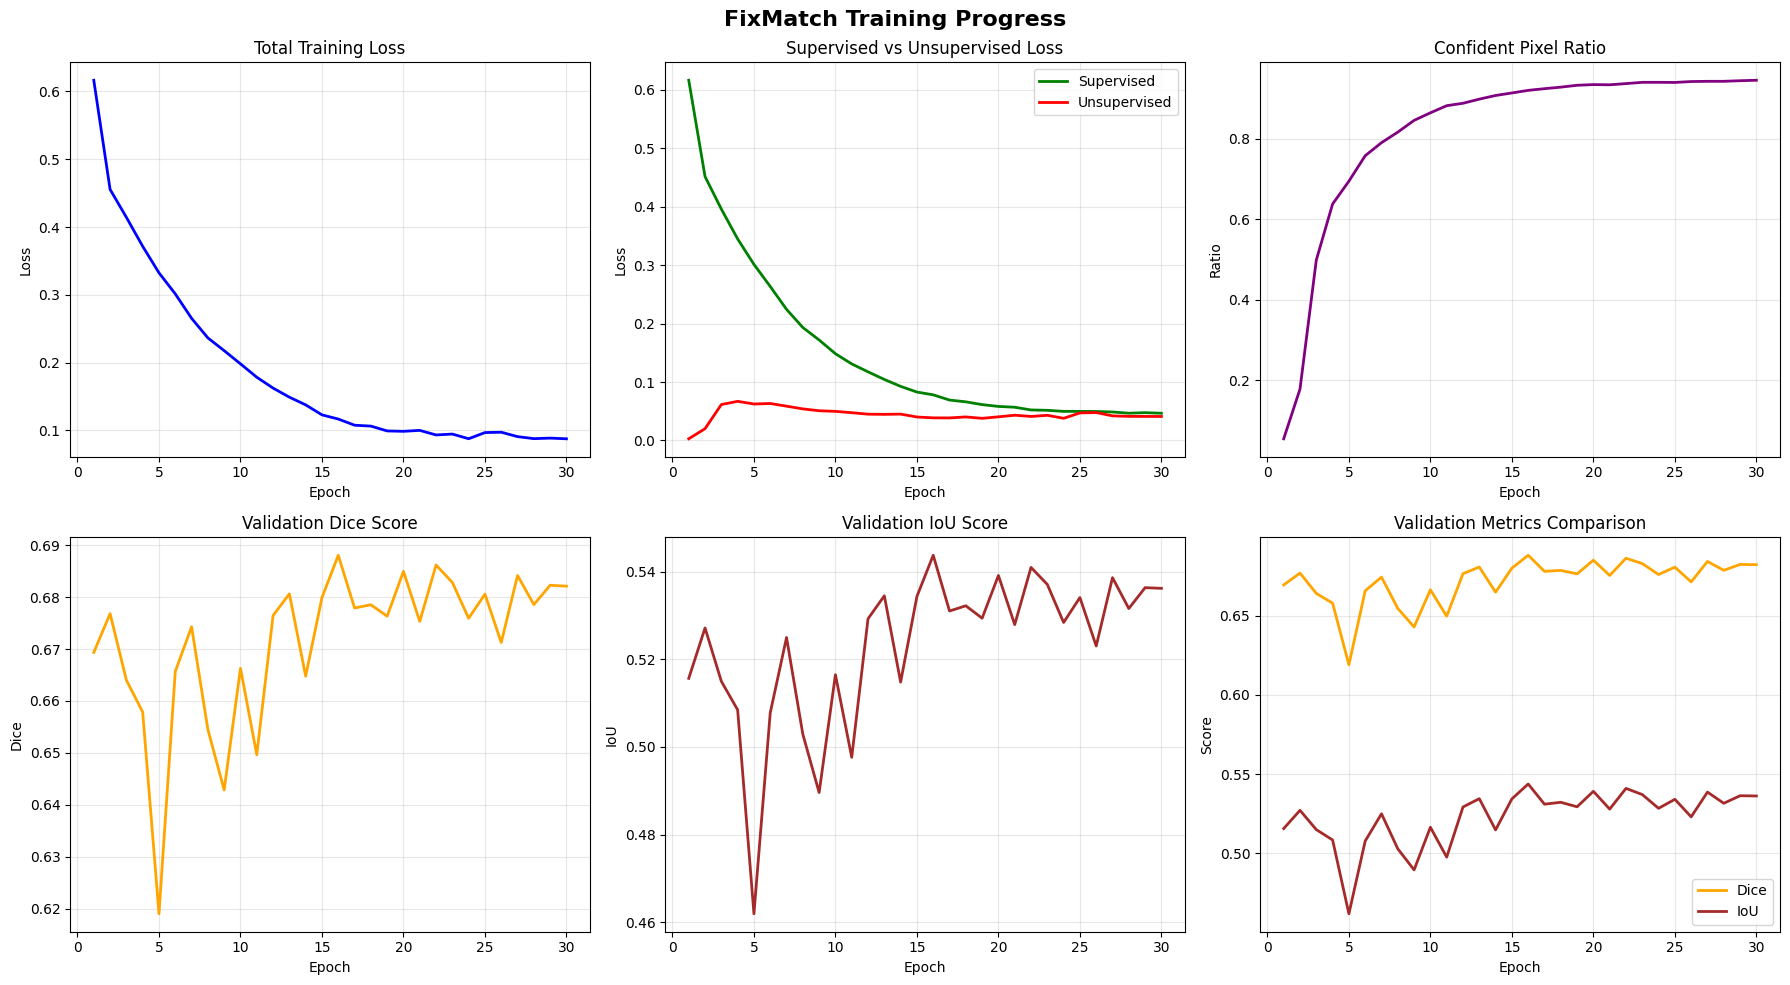

In [13]:
# ==========================================
# 13. VISUALIZATION
# ==========================================
print("\n" + "=" * 70)
print("🎨 STEP 9: VISUALIZING RESULTS")
print("=" * 70)

def plot_fixmatch_training(fixmatch_history):
    """Plot FixMatch training curves"""
    epochs = range(1, len(fixmatch_history['train_loss']) + 1)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Total loss
    axes[0, 0].plot(epochs, fixmatch_history['train_loss'], 'b-', linewidth=2)
    axes[0, 0].set_title('Total Training Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, alpha=0.3)

    # Supervised vs Unsupervised loss
    axes[0, 1].plot(epochs, fixmatch_history['sup_loss'], 'g-', linewidth=2, label='Supervised')
    axes[0, 1].plot(epochs, fixmatch_history['unsup_loss'], 'r-', linewidth=2, label='Unsupervised')
    axes[0, 1].set_title('Supervised vs Unsupervised Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Confident ratio
    axes[0, 2].plot(epochs, fixmatch_history['confident_ratio'], 'purple', linewidth=2)
    axes[0, 2].set_title('Confident Pixel Ratio')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Ratio')
    axes[0, 2].grid(True, alpha=0.3)

    # Validation Dice
    axes[1, 0].plot(epochs, fixmatch_history['val_dice'], 'orange', linewidth=2)
    axes[1, 0].set_title('Validation Dice Score')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Dice')
    axes[1, 0].grid(True, alpha=0.3)

    # Validation IoU
    axes[1, 1].plot(epochs, fixmatch_history['val_iou'], 'brown', linewidth=2)
    axes[1, 1].set_title('Validation IoU Score')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('IoU')
    axes[1, 1].grid(True, alpha=0.3)

    # Combined metrics
    axes[1, 2].plot(epochs, fixmatch_history['val_dice'], 'orange', linewidth=2, label='Dice')
    axes[1, 2].plot(epochs, fixmatch_history['val_iou'], 'brown', linewidth=2, label='IoU')
    axes[1, 2].set_title('Validation Metrics Comparison')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Score')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)

    plt.suptitle('FixMatch Training Progress', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Plot training history
print("\n📈 Plotting training history...")
plot_fixmatch_training(fixmatch_history)


🖼️ Visualizing sample predictions...


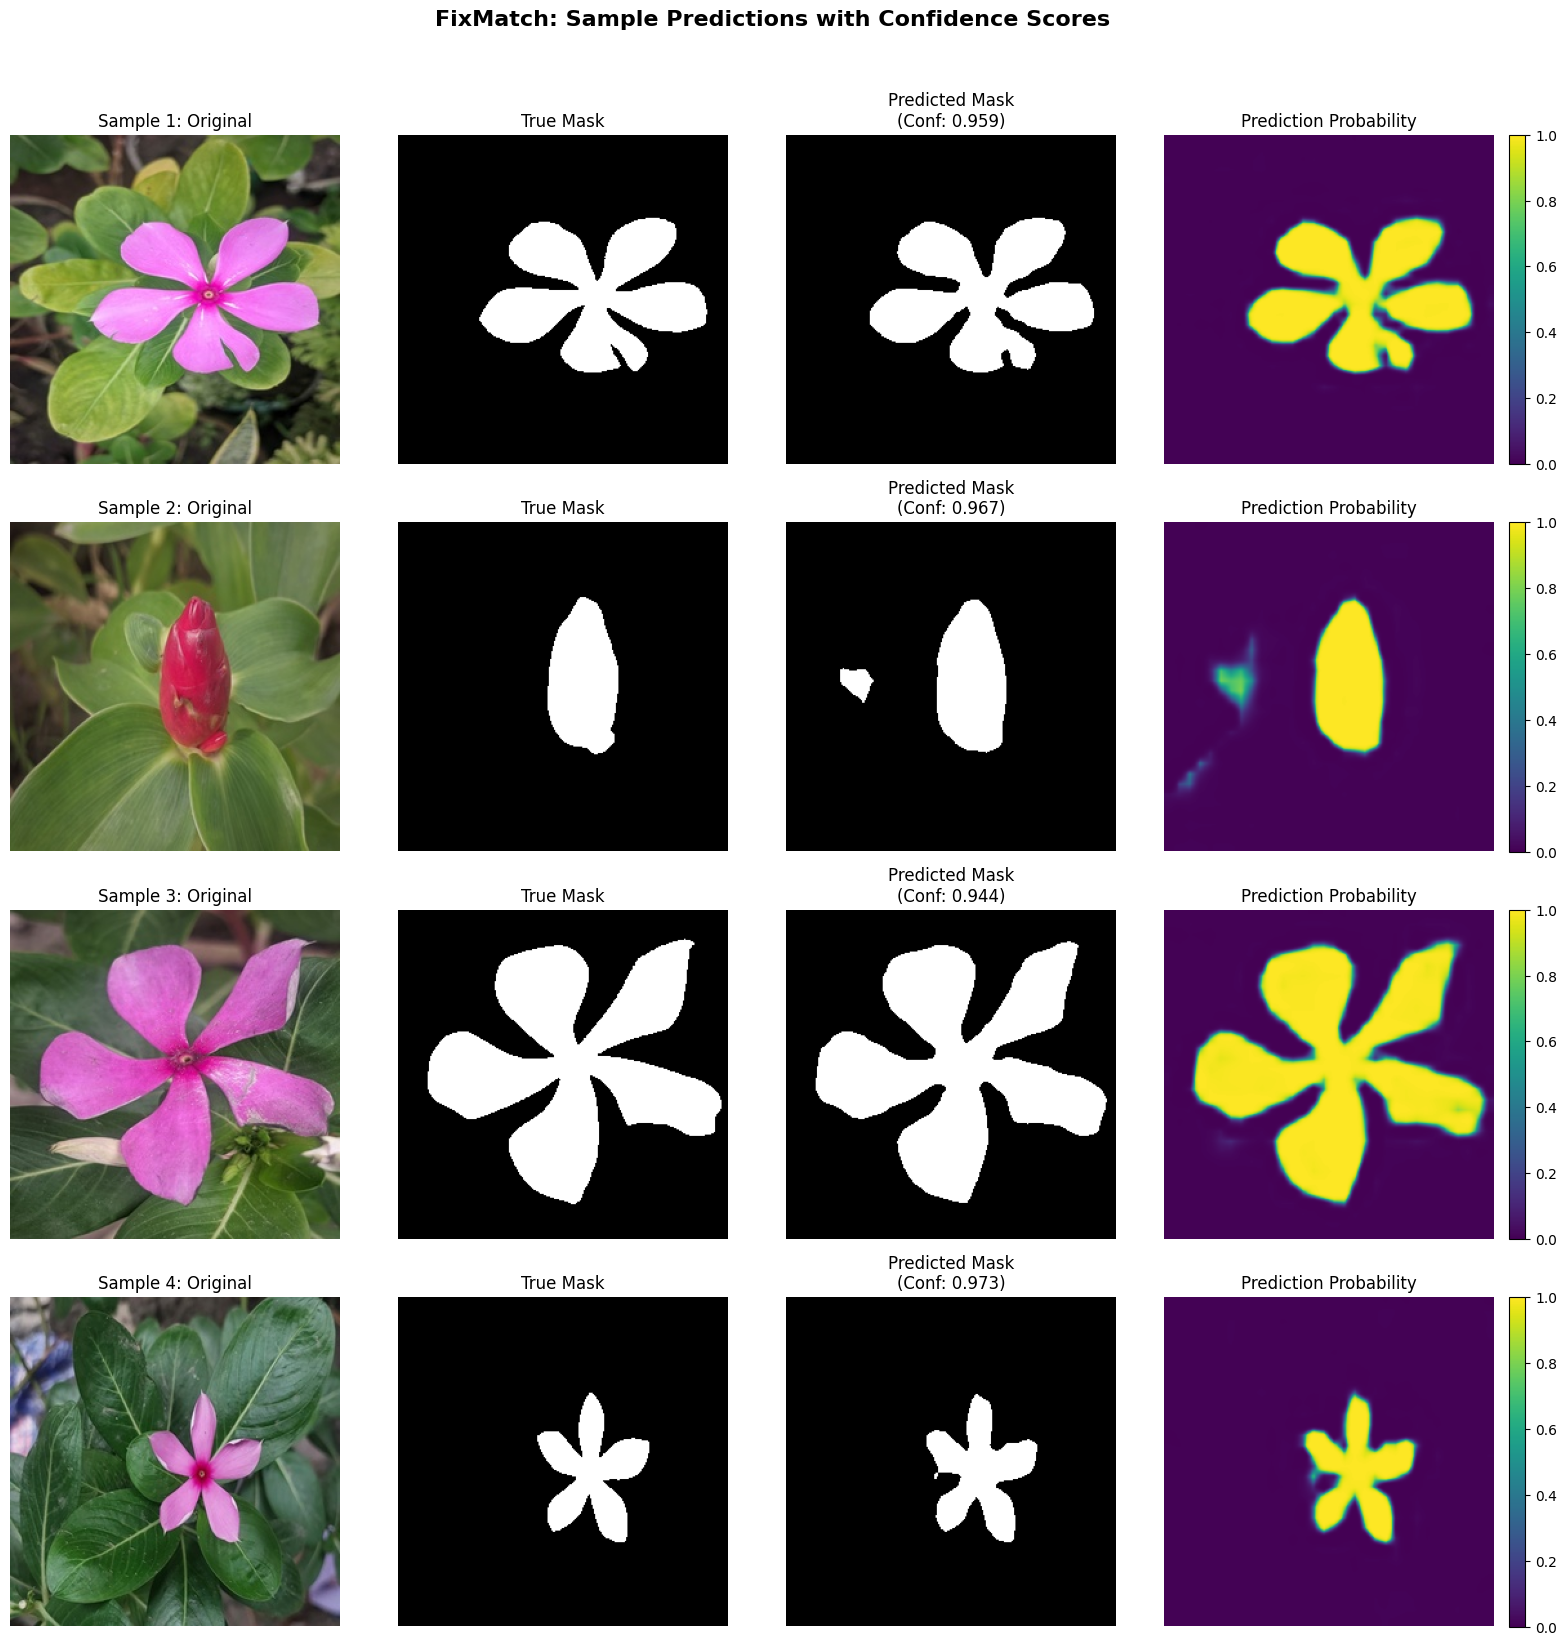


📊 Confidence Statistics for 4 samples:
  • Average confidence: 0.9608
  • Min confidence: 0.9441
  • Max confidence: 0.9728
  • Std confidence: 0.0108


In [14]:
# ==========================================
# 14. VISUALIZE PREDICTIONS
# ==========================================
print("\n🖼️ Visualizing sample predictions...")

def visualize_predictions(model, dataloader, num_samples=6):
    """Visualize model predictions on sample images"""
    model.eval()

    # Get a batch of test data
    images, true_masks = next(iter(dataloader))

    # Make predictions
    with torch.no_grad():
        images = images[:num_samples].to(DEVICE)
        true_masks = true_masks[:num_samples].to(DEVICE)

        preds, _ = model(images, return_both=True)
        probs = torch.sigmoid(preds)
        pred_masks = (probs > 0.5).float()

        # Calculate confidence
        confidence = torch.abs(probs - 0.5) * 2
        avg_confidence = confidence.mean(dim=[1, 2, 3]).cpu().numpy()

    # Move to CPU for visualization
    images = images.cpu()
    true_masks = true_masks.cpu()
    pred_masks = pred_masks.cpu()
    probs = probs.cpu()

    # Create figure
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))

    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(num_samples):
        # Original image
        axes[i, 0].imshow(images[i].permute(1, 2, 0))
        axes[i, 0].set_title(f'Sample {i+1}: Original')
        axes[i, 0].axis('off')

        # True mask
        axes[i, 1].imshow(true_masks[i].squeeze(), cmap='gray')
        axes[i, 1].set_title('True Mask')
        axes[i, 1].axis('off')

        # Predicted mask
        axes[i, 2].imshow(pred_masks[i].squeeze(), cmap='gray')
        axes[i, 2].set_title(f'Predicted Mask\n(Conf: {avg_confidence[i]:.3f})')
        axes[i, 2].axis('off')

        # Prediction probability heatmap
        im = axes[i, 3].imshow(probs[i].squeeze(), cmap='viridis', vmin=0, vmax=1)
        axes[i, 3].set_title('Prediction Probability')
        axes[i, 3].axis('off')
        plt.colorbar(im, ax=axes[i, 3], fraction=0.046, pad=0.04)

    plt.suptitle('FixMatch: Sample Predictions with Confidence Scores',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Print confidence statistics
    print(f"\n📊 Confidence Statistics for {num_samples} samples:")
    print(f"  • Average confidence: {avg_confidence.mean():.4f}")
    print(f"  • Min confidence: {avg_confidence.min():.4f}")
    print(f"  • Max confidence: {avg_confidence.max():.4f}")
    print(f"  • Std confidence: {avg_confidence.std():.4f}")

# Visualize predictions
visualize_predictions(fixmatch_model, test_dl, num_samples=4)


📊 Computing confusion matrix...


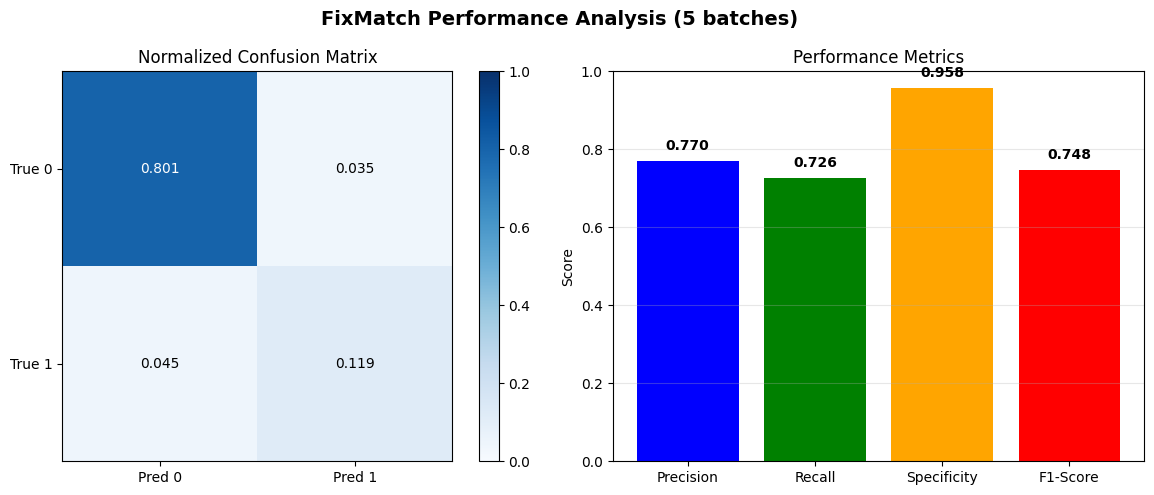


📊 Detailed Statistics (5 batches, 10,485,760.0 pixels):
  • True Positives:  1,244,269.0 (11.87%)
  • False Positives: 370,948.0 (3.54%)
  • False Negatives: 469,617.0 (4.48%)
  • True Negatives:  8,400,926.0 (80.12%)

✅ VISUALIZATION COMPLETE!


In [15]:
# ==========================================
# 15. CONFUSION MATRIX VISUALIZATION
# ==========================================
print("\n📊 Computing confusion matrix...")

def plot_confusion_matrix_stats(model, dataloader, num_batches=10):
    """Plot confusion matrix statistics"""
    model.eval()

    TP_total, FP_total, FN_total, TN_total = 0, 0, 0, 0
    batches_processed = 0

    with torch.no_grad():
        for i, (images, masks) in enumerate(dataloader):
            if i >= num_batches:
                break

            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            preds, _ = model(images, return_both=True)
            probs = torch.sigmoid(preds)
            pred_masks = (probs > 0.5).float()

            # Calculate confusion matrix components
            TP = (pred_masks * masks).sum()
            FP = (pred_masks * (1 - masks)).sum()
            FN = ((1 - pred_masks) * masks).sum()
            TN = ((1 - pred_masks) * (1 - masks)).sum()

            TP_total += TP.item()
            FP_total += FP.item()
            FN_total += FN.item()
            TN_total += TN.item()
            batches_processed += 1

    # Normalize
    total = TP_total + FP_total + FN_total + TN_total
    TP_norm = TP_total / total
    FP_norm = FP_total / total
    FN_norm = FN_total / total
    TN_norm = TN_total / total

    # Create confusion matrix
    cm = np.array([[TN_norm, FP_norm],
                   [FN_norm, TP_norm]])

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Confusion matrix heatmap
    im = ax[0].imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax[0].set_xticks([0, 1])
    ax[0].set_yticks([0, 1])
    ax[0].set_xticklabels(['Pred 0', 'Pred 1'])
    ax[0].set_yticklabels(['True 0', 'True 1'])
    ax[0].set_title('Normalized Confusion Matrix')

    # Add text annotations
    for i in range(2):
        for j in range(2):
            text = ax[0].text(j, i, f'{cm[i, j]:.3f}',
                            ha="center", va="center",
                            color="white" if cm[i, j] > 0.5 else "black")

    plt.colorbar(im, ax=ax[0])

    # Metrics bar chart
    metrics = {
        'Precision': TP_total / (TP_total + FP_total + 1e-6),
        'Recall': TP_total / (TP_total + FN_total + 1e-6),
        'Specificity': TN_total / (TN_total + FP_total + 1e-6),
        'F1-Score': (2 * TP_total) / (2 * TP_total + FP_total + FN_total + 1e-6)
    }

    colors = ['blue', 'green', 'orange', 'red']
    ax[1].bar(metrics.keys(), metrics.values(), color=colors)
    ax[1].set_title('Performance Metrics')
    ax[1].set_ylabel('Score')
    ax[1].set_ylim(0, 1)
    ax[1].grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for i, (key, value) in enumerate(metrics.items()):
        ax[1].text(i, value + 0.02, f'{value:.3f}',
                  ha='center', va='bottom', fontweight='bold')

    plt.suptitle(f'FixMatch Performance Analysis ({batches_processed} batches)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print detailed statistics
    print(f"\n📊 Detailed Statistics ({batches_processed} batches, {total:,} pixels):")
    print(f"  • True Positives:  {TP_total:,} ({TP_norm:.2%})")
    print(f"  • False Positives: {FP_total:,} ({FP_norm:.2%})")
    print(f"  • False Negatives: {FN_total:,} ({FN_norm:.2%})")
    print(f"  • True Negatives:  {TN_total:,} ({TN_norm:.2%})")

# Plot confusion matrix
plot_confusion_matrix_stats(fixmatch_model, test_dl, num_batches=5)

print("\n" + "=" * 70)
print("✅ VISUALIZATION COMPLETE!")
print("=" * 70)